# Ejemplo Redes Neuronales
## 1) Importar librerías necesarias
Esta celda carga todas las dependencias necesarias para entrenar y evaluar una red neuronal simple.
* **numpy** para operaciones numéricas y manipulación de matrices;
* **matplotlib.pyplot** para visualizar imágenes, curvas de entrenamiento y resultados;
* **tensorflow.keras.datasets.mnist** para cargar de forma simple el conjunto de datos MNIST ya particionado en train/test;
* **tensorflow.keras.utils.to_categorical** para convertir etiquetas enteras a vectores one-hot necesarios para la función de pérdida categorical_crossentropy;
* **Sequential**, **Dense**, **Flatten** y **Adam** para construir, compilar y optimizar la red neuronal feedforward.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

## 2) Cargar MNIST y observar estructura
MNIST contiene 70,000 imágenes de números escritos a mano (28×28 pixeles, escala de grises).

Esta celda carga MNIST con **mnist.load_data()** que devuelve tuplas (X_train, y_train), (X_test, y_test):

* 60,000 imágenes de entrenamiento
* 10,000 imágenes de prueba
* Cada imagen es de 28×28 pixeles en escala de grises
* Las etiquetas son enteros del 0 al 9

Tamaño de X_train: (60000, 28, 28)
Tamaño de y_train: (60000,)
Tamaño de X_test: (10000, 28, 28)


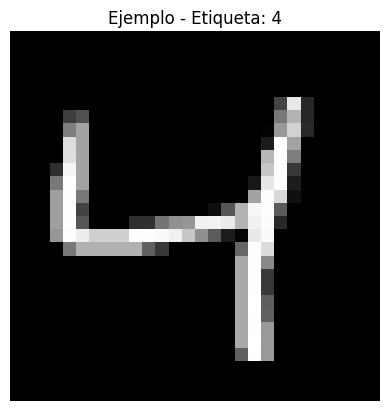

In [24]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de X_test:", X_test.shape)

# Mostrar un ejemplo
plt.imshow(X_train[2], cmap='gray')
plt.title(f"Ejemplo - Etiqueta: {y_train[2]}")
plt.axis('off')
plt.show()

## 3) Preprocesamiento
Las redes neuronales funcionan mejor cuando:
* **Normalizamos** los pixeles de 0–255 a un rango 0–1. Esto mejora la estabilidad numérica y acelera el aprendizaje.
* Convertimos las etiquetas (0–9) en vectores **one-hot**, por ejemplo:
3 → [0,0,0,1,0,0,0,0,0,0]

In [3]:
# Normalizar de [0,255] → [0,1]
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Después de normalizar:")
print("X_train_norm shape:", X_train_norm.shape)
print("y_train_cat shape:", y_train_cat.shape)

Después de normalizar:
X_train_norm shape: (60000, 28, 28)
y_train_cat shape: (60000, 10)


## 4) Construir una red neuronal simple

En esta celda definimos la arquitectura del modelo usando Keras:
* **Flatten()** convierte cada imagen 28×28 en un vector de 784 componentes.
* **Dense(128, ReLU)** es una capa totalmente conectada que aprende patrones no lineales de los dígitos.
* **Dense(10, Softmax)** produce una probabilidad para cada una de las 10 clases.
  
Esta es una red neuronal simple pero suficiente para demostrar el flujo completo de clasificación.

In [21]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5) Compilar el modelo

Aquí configuramos cómo va a aprender la red:

* **Loss: categorical crossentropy** → ideal para problemas de clasificación con múltiples clases.
* **Optimizer: Adam** → rápido, estable y ampliamente usado.
* **Metric: accuracy** → porcentaje de predicciones correctas.

Esta celda no entrena el modelo; solo define las reglas del entrenamiento.

In [5]:
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 6) Entrenar el modelo

En esta celda comenzamos el proceso de aprendizaje con model.fit():
* **epochs:** número de veces que la red verá todos los datos.
* **batch_size:** tamaño de cada lote usado para actualizar los pesos.
* **validation_split:** reservamos un porcentaje del entrenamiento para evaluar cómo aprende el modelo en datos que no ha visto.
*  **shuffle** mezcla los datos del datatrain al inicio de cada epoca
*  **verbose** define qué tan detallado es el texto que Keras imprime durante el entrenamiento.

Valores posibles de verbose:<br>
0	No muestra nada <br>
1	Barra de progreso por época (el más común)<br>
2	Una línea por época sin barra de progreso<br>
El resultado será un historial que incluye la pérdida y accuracy en cada época, tanto para entrenamiento como para validación.

In [6]:
history = model.fit(
    X_train_norm, y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8957 - loss: 0.3803 - val_accuracy: 0.9538 - val_loss: 0.1747
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9495 - loss: 0.1764 - val_accuracy: 0.9652 - val_loss: 0.1257
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9629 - loss: 0.1266 - val_accuracy: 0.9683 - val_loss: 0.1097
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9714 - loss: 0.0986 - val_accuracy: 0.9737 - val_loss: 0.0904
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9770 - loss: 0.0796 - val_accuracy: 0.9770 - val_loss: 0.0841


## 7) Graficar Accuracy y perdida

Aquí visualizamos el historial generado durante el entrenamiento.
Mostraremos:

* **Evolución de la pérdida** (loss)
* **Evolución de la precisión** (accuracy)

Estas gráficas permiten evaluar si hubo sobreajuste, subajuste o un aprendizaje adecuado.

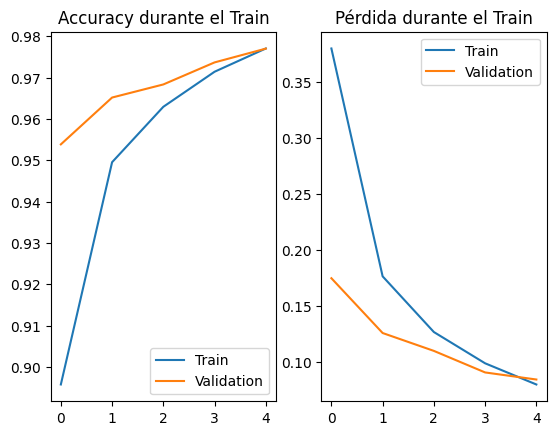

In [8]:
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy durante el Train")
plt.legend()

# Pérdida
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Pérdida durante el Train")
plt.legend()

plt.show()

## 8) Evaluar el modelo

En esta celda probamos el modelo con las 10,000 imágenes que nunca vio durante el entrenamiento.
Esto nos permite medir su capacidad real de generalización.

Mostramos:
* Pérdida en test
* Accuracy en test

Estos valores suelen ser ligeramente inferiores a los de validación.

In [9]:
test_loss, test_acc = model.evaluate(X_test_norm, y_test_cat, verbose=0)

print(f"Accuracy en test: {test_acc:.4f}")
print(f"Pérdida en test: {test_loss:.4f}")

Accuracy en test: 0.9719
Pérdida en test: 0.0916


## 9) Predicciones

Aquí seleccionamos una imagen del conjunto de prueba, la mostramos y obtenemos la predicción del modelo.
Mostramos:

* Imagen real
* Etiqueta verdadera
* Etiqueta predicha
* Probabilidad estimada por el modelo

Esto ayuda a entender cómo interpreta el modelo un dato individual.

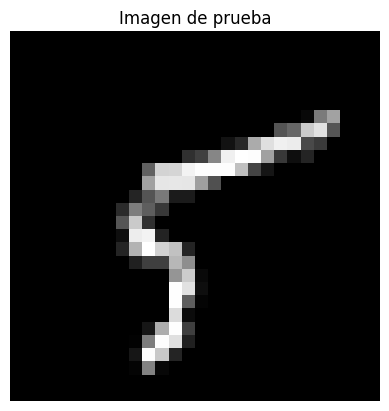

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicción de la red: 5
Etiqueta real: 5


In [10]:
index = 59  # Cambiar para probar otros

plt.imshow(X_test[index], cmap='gray')
plt.title("Imagen de prueba")
plt.axis('off')
plt.show()

pred = model.predict(X_test_norm[index].reshape(1,28,28))
predicted_digit = np.argmax(pred)

print("Predicción de la red:", predicted_digit)
print("Etiqueta real:", y_test[index])

## 10) Mostrar varias predicciones

Finalmente mostramos varias imágenes con sus predicciones.
Se resaltan:

* Etiquetas correctas (en verde)
* Etiquetas incorrectas (en rojo)

Esto permite analizar de forma visual qué tipos de dígitos confunde más el modelo y discutir posibles mejoras (más capas, CNNs, regularización, etc.).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


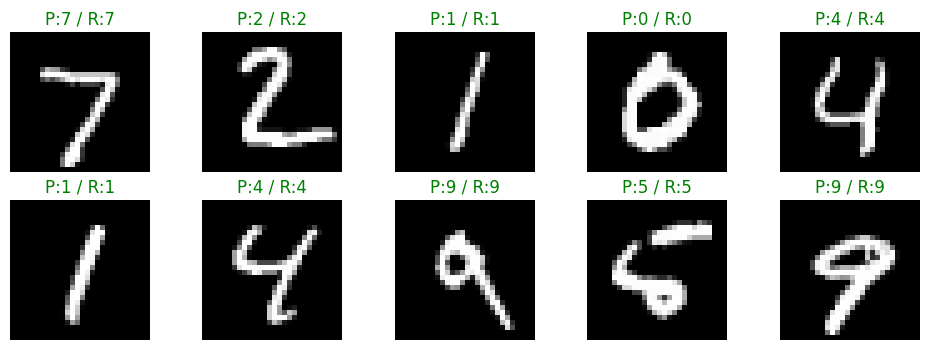

In [12]:
num_images = 10
plt.figure(figsize=(12,4))

for i in range(num_images):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    
    pred = model.predict(X_test_norm[i].reshape(1,28,28))
    pred_digit = np.argmax(pred)
    
    color = "green" if pred_digit == y_test[i] else "red"
    plt.title(f"P:{pred_digit} / R:{y_test[i]}", color=color)
    plt.axis('off')

plt.show()